In [1]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AnyMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver

c:\ML-DL\AgenticAI-LangGraph\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0
)

In [4]:

def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

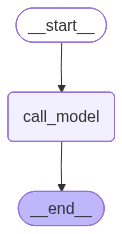

In [6]:
graph = builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Subham."}]})

{'messages': [HumanMessage(content='Hi! My name is Subham.', additional_kwargs={}, response_metadata={}, id='e05fc446-d388-40cb-93f5-e18e30eec2c3'),
  AIMessage(content='Hello Subham! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi! My name is Subham." We should greet them, maybe ask how we can help. No special instructions.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'We need to respond. The user says "Hi! My name is Subham." We should greet them, maybe ask how we can help. No special instructions.'}]}, response_metadata={'model_name': 'openai/gpt-oss-20b:free', 'id': 'gen-1783677302-Puo14lvMgyi2ORN4VzPt', 'created': 1783677302, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 3.92e-06, 'upstream_inference_prompt_cost': 1.1165e-06, 'upstream_inference_cost

In [8]:

graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='ce93df7a-7cb5-424d-abb5-633c2c121dc0'),
  AIMessage(content='I’m not sure—could you let me know what you’d like me to call you?', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" This is a trick question. We don\'t know the user\'s name. We should respond that we don\'t know. We can ask for clarification. We should be polite.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user asks "What is my name?" This is a trick question. We don\'t know the user\'s name. We should respond that we don\'t know. We can ask for clarification. We should be polite.'}]}, response_metadata={'model_name': 'openai/gpt-oss-20b:free', 'id': 'gen-1783677321-Cv9VMzNACJgqDtSjoz2z', 'created': 1783677321, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'u

### Adding short term memory

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

In [11]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [12]:
config = {"configurable": {"thread_id": "thread-1"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Subham."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Subham.', additional_kwargs={}, response_metadata={}, id='7bd0ec3c-c314-4f3e-aa42-9c5f14bd7f9a'),
  AIMessage(content='Hello Subham! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi! My name is Subham." We should greet them, maybe ask how we can help. No special instructions.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'We need to respond. The user says "Hi! My name is Subham." We should greet them, maybe ask how we can help. No special instructions.'}]}, response_metadata={'model_name': 'openai/gpt-oss-20b:free', 'id': 'gen-1783677434-WVPRGRXKLMmbB9dReM0o', 'created': 1783677434, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 3.92e-06, 'upstream_inference_prompt_cost': 1.1165e-06, 'upstream_inference_cost

In [15]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Subham.', additional_kwargs={}, response_metadata={}, id='7bd0ec3c-c314-4f3e-aa42-9c5f14bd7f9a'),
  AIMessage(content='Hello Subham! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi! My name is Subham." We should greet them, maybe ask how we can help. No special instructions.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'We need to respond. The user says "Hi! My name is Subham." We should greet them, maybe ask how we can help. No special instructions.'}]}, response_metadata={'model_name': 'openai/gpt-oss-20b:free', 'id': 'gen-1783677434-WVPRGRXKLMmbB9dReM0o', 'created': 1783677434, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 3.92e-06, 'upstream_inference_prompt_cost': 1.1165e-06, 'upstream_inference_cost

In [16]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Subham.
- AIMessage : Hello Subham! 👋 How can I help you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Subham.
- HumanMessage : What is my name?
- AIMessage : Your name is Subham.
